In [1]:
%matplotlib inline

In [30]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from sktime.transformations.series.outlier_detection import HampelFilter
import os
import sys
from pathlib import Path

In [3]:
notebook_path = Path(os.getcwd()).resolve()

def get_root(path):
    for parent in [path] + list(path.parents):
        if (parent / "static_data").exists():
            return parent
    return path

PROJECT_ROOT = get_root(notebook_path)
DATA_DIR = PROJECT_ROOT / "static_data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Source:  {DATA_DIR}")

Project Root: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project
Data Source:  D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Data_Science\08_final_project\static_data


In [4]:
#Import project modules here

BASE_URL = "https://storage.googleapis.com/softuni_data_science_final_project_kamend1/static_data/"

import importlib
from src.data_pipeline_utils import data_fetching_handling as data_pipe
import src.plotting_utils.plotting_utils as plot_utils
importlib.reload(plot_utils)
importlib.reload(data_pipe)

<module 'src.data_pipeline_utils.data_fetching_handling' from 'D:\\Users\\kamen.dimitrov\\Desktop\\SOFTUNI\\AI_and_ML_upskill_program\\Data_Science\\08_final_project\\src\\data_pipeline_utils\\data_fetching_handling.py'>

# Motivation, Background, and Objectives of the Project

This project represents a natural continuation of my prior work in the “Math for Developers” course at SoftUni, where I sought to demonstrate through practical implementation that core mathematical disciplines—linear algebra, calculus, probability theory, statistics, and combinatorics—are not abstract academic constructs, but foundational tools in modern financial science and practice. That earlier effort is available at my GitHub repository: [SoftUni Math for Developers Final Project](https://github.com/Kamend1/math_for_developers_final_project)

In that Math project, I focused primarily on applying the mathematical concepts in price-based modeling and portfolio construction, while in this current work I aim to expand the analytical scope attempting to successfully utilize concepts taught in the Data Science corse at SoftUni toward obtaining relevant data, handling data, time-series analysis, hypothesis testing, and integrating textual data and sentiment as an additional informational layer.

The broader motivation is rooted in the ongoing transformation of financial markets. Quantitative methods are no longer confined to specialized institutions; with the rapid advancement of computing power and the democratization of programming tools such as Python, they are becoming mainstream. Algorithmic investing, once the domain of hedge funds and proprietary trading desks, is now accessible to a much wider audience. High-frequency trading and systematic strategies have already reshaped market microstructure, building upon earlier paradigms such as technical analysis, where practitioners attempted to visually identify patterns in price movements. Today, the frontier extends further into machine learning and natural language processing (NLP), where textual information—earnings announcements, filings, and corporate disclosures—can be transformed into structured signals.

With the availability of pre-trained NLP models such as FinBERT, and the relative ease of deploying them, sentiment analysis has emerged as a promising avenue for extracting potential buy and sell signals. This project seeks to explore whether such sentiment-based signals can provide statistically meaningful insights into short-term price behavior.

From a professional perspective, I approach this topic with both curiosity and skepticism. I have over 20 years of personal and professional experience in capital markets. I am a certified independent appraiser of real estate, financial assets, and financial institutions, a member of the CFA Institute since 2009, and a licensed investment consultant from the Bulgarian Financial Supervision Commission. Throughout my career, I have adhered to the principle that intrinsic value is derived from the fundamental characteristics of an asset, and that past price performance is not a reliable predictor of future valuation. Consequently, I have traditionally placed limited weight on purely statistical or sentiment-based forecasting approaches.

However, I am also deeply interested in technology and continuous learning. Since 2023, I have been actively developing my programming skills in Python through SoftUni, accumulating approximately 150 credits and participating in the AI and ML upskill program. My first exposure to practical applications of artificial neural networks dates back to 2005, during my time as a credit analyst and junior portfolio manager at Voyageur Asset Management in Minneapolis (now part of RBC Asset Management (US) Inc.). At that time, we utilized a licensed ANN-based system to assess credit risk in high-yield corporate bond issuers. This early experience sparked a long-standing interest in quantitative modeling and machine learning, well before the emergence of modern large language models.

In my current role as an executive in a manufacturing company, I emphasize a data-driven approach to decision-making. I actively seek to reduce cognitive biases and adapt strategies based on evolving data and conditions. This project is an extension of that mindset. I aim to construct a framework that integrates multiple data sources: historical price data from Yahoo Finance via the yfinance API, financial disclosures from the SEC EDGAR database, and textual data from corporate filings such as 8-K reports and 10-Q Management Discussion & Analysis sections. Through feature engineering on price data and sentiment extraction from textual data, I intend to define and test trading signals.

The primary objective is to determine whether these signals exhibit statistically significant relationships with subsequent stock price movements. The project will focus on a universe of 30 large-cap stocks across different sectors. I will use a 10-year dataset, dividing it into two periods: the first five years for portfolio optimization (including efficient frontier construction and weight determination), and the second five years for time-series analysis and signal testing. The trading framework will simulate a long-only strategy, where positions are initiated upon buy signals and closed upon sell signals, subject to constraints such as maximum position size and transaction costs.

A parallel objective is to evaluate sentiment-driven signals. Using the FinBERT model, I will analyze textual disclosures and test whether sentiment scores have predictive power over short-term horizons.

**A significant setback** during the initial phase of the project was related to data sourcing. I initially intended to use earnings call transcripts, which are publicly discussed but not freely distributed. Available datasets, such as those on Kaggle (including the Motley Fool dataset), appear to have been compiled through scraping in violation of terms and conditions. Similar concerns apply to datasets on other platforms, likely sourced from providers such as Seeking Alpha or Financial Modeling Prep. Given these **legal and ethical considerations**, I decided to abandon this approach despite having already invested substantial time in it. Instead, I pivoted to using officially available regulatory filings, acknowledging that these may contain management bias and may not yield strong statistical results. I will perform sentiment analysis on texts containing press releases in 8-K SEC filings of the companies I selected, as well as the management discussion and analysis in the quarterly earnings reports filed as 10-Q by the management. The texts will be obtain via **legaly scraping** data from the SEC's EDGAR database applying asynchronous methods and the help of the [edgartools Python library](https://edgartools.readthedocs.io/en/latest/) and complying with SEC's scraping allowance limits. 

This project is driven entirely by personal curiosity. I approach it with an open and unbiased mindset, fully prepared for the possibility that the hypotheses may not hold. I will use various coding resources and may seek assistance from language models where appropriate, but the conceptual framework, data selection, feature engineering, and hypothesis testing are my own. The results—whether successful or not—will reflect my own reasoning, including any and all methodological limitations, fallacies due to lack of high-level knowledge and experience.

The project is published on my GitHub repository under an MIT license. It is important to emphasize that this work does not constitute investment advice or a recommendation. Rather, it is an exploratory exercise at the intersection of finance, data science, and machine learning for purely academic, personal development, and learning purposes. I hope everyone who finds the repo can learn and obtain something new from it.

Let us proceed with the analysis.

The first stage builds a clean financial dataset and explores the statistical properties of returns, including volatility, outliers, distribution shape, and persistence. Later stages test whether these features can be converted into predictive signals for subsequent returns.

# 1. Prepare data using the pipeline

In [5]:
tickers = [
    "AAPL", "GOOG", "MSFT", "NVDA",
    "JPM", "BAC", "F", "UPS", "WMT", "TGT",
    "VZ", "T", "FE", "PFE", "JNJ", "DIS",
    "V", "MCD", "NKE", "XOM", "CVX",
    "CAT", "DE", "LMT", "AMD", "INTC", "ORCL", 
    "CRM", "CB", "PG"
]

In [6]:
# all_df_shapes = {}

# for ticker in tickers:
#     data = data_pipe.save_10_year_single_stock_data_to_csv(ticker)
#     return_data = data_pipe.create_returns_and_save(data, ticker)
#     all_df_shapes[ticker] = return_data.shape

# all_same = set(all_df_shapes.values())
# print(f"{len(all_same)} - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks.")

In [7]:
AAPL_data = data_pipe.fetch_raw_data('AAPL', PROJECT_ROOT)
return_data = data_pipe.fetch_returns_data('AAPL', PROJECT_ROOT)

return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct
Date,,,,,,,,,
2016-04-01,24.910585,24.912851,24.505185,24.636544,103496000,0.009175,0.009133,0.917523,0.913340
2016-04-04,25.166506,25.408840,24.973996,25.007968,149424800,0.010274,0.010221,1.027356,1.022115
2016-04-05,24.869822,25.078185,24.781494,24.801878,106314800,-0.011789,-0.011859,-1.178885,-1.185889
2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400,0.010472,0.010418,1.047239,1.041794
2016-04-07,24.582186,25.007968,24.487064,24.901522,127207600,-0.021810,-0.022051,-2.180965,-2.205100
...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300,0.000596,0.000596,0.059642,0.059624
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700,0.003894,0.003887,0.389444,0.388687
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700,0.001069,0.001068,0.106882,0.106825


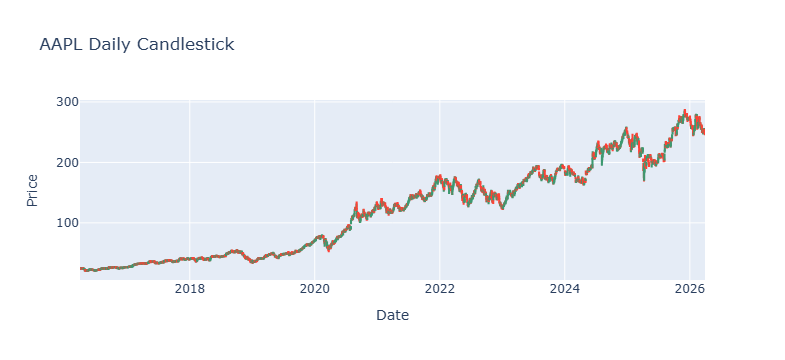

In [8]:
fig = plot_utils.create_candlestick_graph('AAPL', PROJECT_ROOT)
fig.show()

# 2. Here we deviate from the previous project. Let's do some time series data exploration
Let's work with the returns dataframe created above

-  the rolling method in Pandas with parameters:
-  window = 21, we choose this for 21 trading days on average in a month
-  min_periods = 1, for the first 20 rows it gradually expands until it reaches 21
-  dropna(), because on the earliest day (first row), column 'std' remains NaN

In [9]:
stats = return_data['log_return'].rolling(window=21, min_periods=1).agg(['mean', 'std'])
return_data = pd.concat([return_data, stats], axis=1)

return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std
Date,,,,,,,,,,,
2016-04-01,24.910585,24.912851,24.505185,24.636544,103496000,0.009175,0.009133,0.917523,0.913340,0.009133,NaN
2016-04-04,25.166506,25.408840,24.973996,25.007968,149424800,0.010274,0.010221,1.027356,1.022115,0.009677,0.000769
2016-04-05,24.869822,25.078185,24.781494,24.801878,106314800,-0.011789,-0.011859,-1.178885,-1.185889,0.002499,0.012446
2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400,0.010472,0.010418,1.047239,1.041794,0.004478,0.010906
2016-04-07,24.582186,25.007968,24.487064,24.901522,127207600,-0.021810,-0.022051,-2.180965,-2.205100,-0.000827,0.015165
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300,0.000596,0.000596,0.059642,0.059624,-0.002675,0.012966
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700,0.003894,0.003887,0.389444,0.388687,-0.003544,0.011777
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700,0.001069,0.001068,0.106882,0.106825,-0.003858,0.011549


In [10]:
#TODO Create a method

N_SIGMAS = 3

return_data["upper"] = return_data["mean"] + N_SIGMAS * return_data["std"]
return_data["lower"] = return_data["mean"] - N_SIGMAS * return_data["std"]

return_data["outlier"] = (
    (return_data["log_return"] > return_data["upper"]) | 
    (return_data["log_return"] < return_data["lower"])
)

return_data = return_data.dropna()
return_data

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std,upper,lower,outlier
Date,,,,,,,,,,,,,,
2016-04-04,25.166506,25.408840,24.973996,25.007968,149424800,0.010274,0.010221,1.027356,1.022115,0.009677,0.000769,0.011985,0.007370,False
2016-04-05,24.869822,25.078185,24.781494,24.801878,106314800,-0.011789,-0.011859,-1.178885,-1.185889,0.002499,0.012446,0.039836,-0.034839,False
2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400,0.010472,0.010418,1.047239,1.041794,0.004478,0.010906,0.037197,-0.028240,False
2016-04-07,24.582186,25.007968,24.487064,24.901522,127207600,-0.021810,-0.022051,-2.180965,-2.205100,-0.000827,0.015165,0.044667,-0.046322,False
2016-04-08,24.609367,24.860759,24.498391,24.665987,94326800,0.001106,0.001105,0.110574,0.110513,-0.000505,0.013587,0.040255,-0.041265,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-24,251.639999,254.830002,249.550003,250.350006,45152300,0.000596,0.000596,0.059642,0.059624,-0.002675,0.012966,0.036224,-0.041574,False
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700,0.003894,0.003887,0.389444,0.388687,-0.003544,0.011777,0.031785,-0.038874,False
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700,0.001069,0.001068,0.106882,0.106825,-0.003858,0.011549,0.030789,-0.038505,False


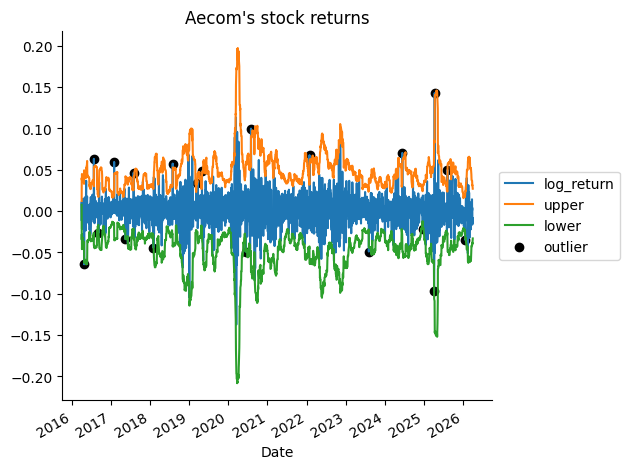

In [11]:
#TODO Create a plot util method

fig, ax = plt.subplots()

return_data[["log_return", "upper", "lower"]].plot(ax=ax)
ax.scatter(return_data.loc[return_data["outlier"]].index, 
           return_data.loc[return_data["outlier"], "log_return"], 
           color="black", label="outlier")
ax.set_title("Aecom's stock returns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()

C:\Users\kamen.dimitrov\AppData\Local\Temp\ipykernel_8112\3422101570.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



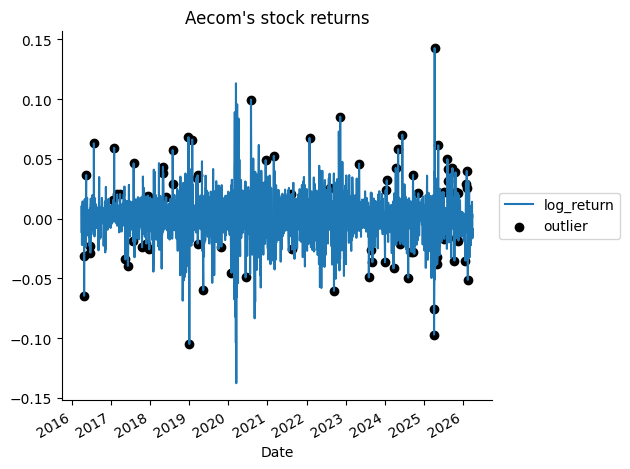

In [12]:
hampel_detector = HampelFilter(window_length=21, return_bool=True)
return_data["outlier_rtn"] = hampel_detector.fit_transform(return_data["log_return"])

fig, ax = plt.subplots()

return_data[["log_return"]].plot(ax=ax)
ax.scatter(return_data.loc[return_data["outlier_rtn"]].index, 
           return_data.loc[return_data["outlier_rtn"], "log_return"], 
           color="black", label="outlier")
ax.set_title("Aecom's stock returns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()

The Hurst Exponent ($H$) is a statistical measure used to classify time series data based on its "memory." In the context of your Python for Finance Cookbook, it is the primary tool for determining if a stock's price is trending, mean-reverting, or just a random walk.Mathematically, it relates to the autocorrelations of the time series and the rate at which the variance of the series increases over time.1. The Three Regimes of $H$The value of $H$ always falls between 0 and 1. Where it lands tells you the "nature" of the asset:Value of HRegimeMarket Behavior$H < 0.5$Mean-Reverting"Anti-persistent." If the price goes up, it is likely to go back down soon. Great for "Pairs Trading."$H = 0.5$Random WalkGeometric Brownian Motion. Past movement has zero influence on future movement (Efficient Market Hypothesis).$H > 0.5$Trending"Persistent." If the price is moving up, it is likely to keep moving up. Ideal for "Momentum Trading."

In [13]:
#TODO Export method in time series analysis
def get_hurst_exponent(ts, lag):
    """Returns the Hurst Exponent of a time series"""
    lags = range(2, lag)
    # Calculate the variance of the differenced series
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    # Use a linear fit to estimate the Hurst Exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0

In [14]:
for lag in [20, 100, 250, 500, 1000]:
    hurst_exp = get_hurst_exponent(return_data["Close"].values, lag)
    print(f"Hurst exponent with {lag} lags: {hurst_exp:.4f}")


Hurst exponent with 20 lags: 0.4468
Hurst exponent with 100 lags: 0.4535
Hurst exponent with 250 lags: 0.3637
Hurst exponent with 500 lags: 0.3159
Hurst exponent with 1000 lags: 0.2230


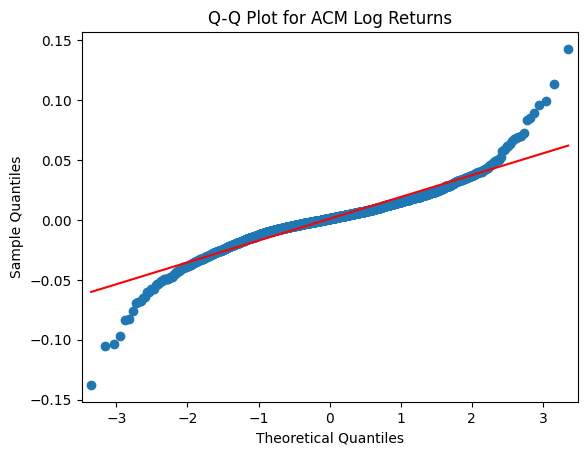

In [15]:
#TODO method in plot utils and explain further
fig = sm.qqplot(return_data['log_return'].dropna(), line='s')
plt.title("Q-Q Plot for ACM Log Returns")
plt.show()

Mean log return in observation period: 0.0009126578136512583,
Variance of log returns in observation period: 0.0003313252717481555,
Standard deviation of log returns in observation period: 0.018202342479696272


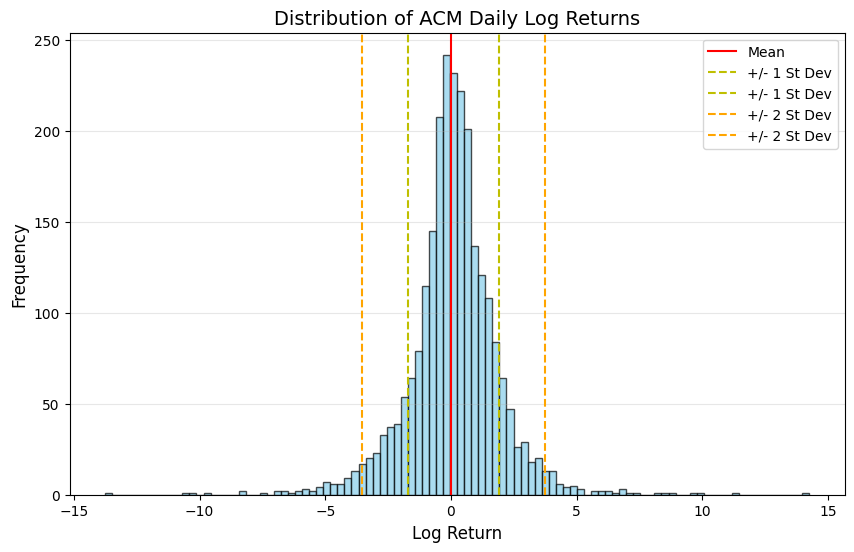

In [16]:
mean = return_data["log_return"].mean()
variance = return_data["log_return"].var()
st_dev = return_data["log_return"].std()

print(f"Mean log return in observation period: {mean},\n"
      f"Variance of log returns in observation period: {variance},\n"
      f"Standard deviation of log returns in observation period: {st_dev}")

ticker = 'ACM'
fig = plot_utils.create_histogram_distribution_daily_log_returns(return_data, ticker, mean, st_dev)
plt.show()

In [17]:
jb_test = scs.jarque_bera(return_data["log_return"].values)

print("---------- Descriptive Statistics ----------")
print("Range of dates:", min(return_data.index.date), "-", max(return_data.index.date))
print("Number of observations:", return_data.shape[0])
print(f"Mean: {return_data.log_return.mean():.4f}")
print(f"Median: {return_data.log_return.median():.4f}")
print(f"Min: {return_data.log_return.min():.4f}")
print(f"Max: {return_data.log_return.max():.4f}")
print(f"Standard Deviation: {return_data.log_return.std():.4f}")
print(f"Skewness: {return_data.log_return.skew():.4f}")
print(f"Kurtosis: {return_data.log_return.kurtosis():.4f}") 
print(f"Jarque-Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.2f}")

---------- Descriptive Statistics ----------
Range of dates: 2016-04-04 - 2026-03-30
Number of observations: 2512
Mean: 0.0009
Median: 0.0010
Min: -0.1377
Max: 0.1426
Standard Deviation: 0.0182
Skewness: -0.0777
Kurtosis: 6.7952
Jarque-Bera statistic: 4812.95 with p-value: 0.00


#TODO Conclusions

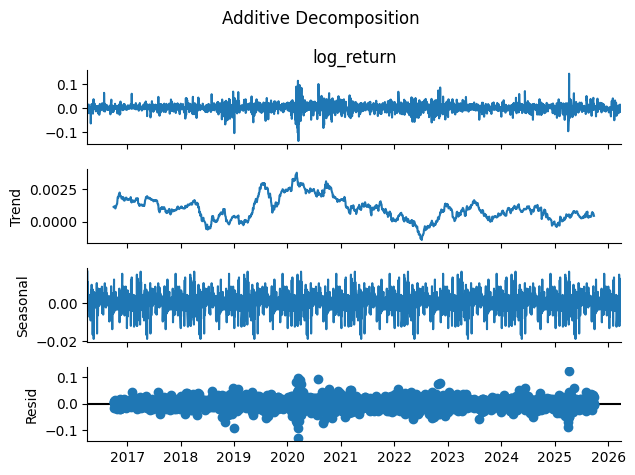

In [23]:
decomposition_results = seasonal_decompose(return_data["log_return"], 
                                           model="additive",
                                          period=252,)
                                            
(
    decomposition_results
    .plot()
    .suptitle("Additive Decomposition")
)

sns.despine()
plt.tight_layout()

Use the STL decomposition:

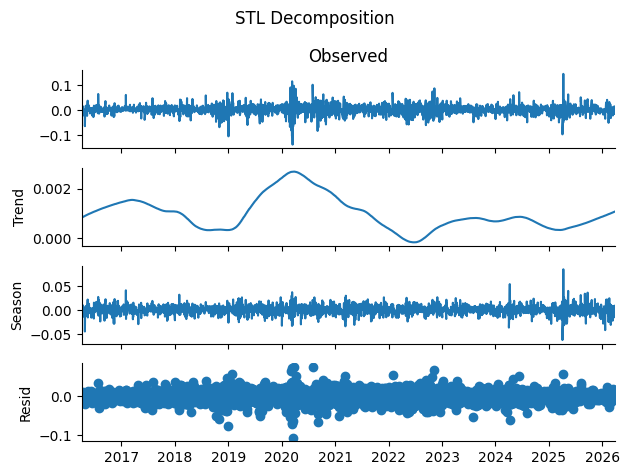

In [27]:
stl_decomposition = STL(return_data[["log_return"]], period=252).fit()
stl_decomposition.plot() \
                 .suptitle("STL Decomposition")

sns.despine()
plt.tight_layout()

##### Seasonal and STL Decomposition Outcome

The STL decomposition produces a visibly cleaner separation of components compared to classical seasonal decomposition. The trend component appears smoother and more stable, indicating that STL is more effective at extracting the underlying direction of the series.

However, despite this improvement, the majority of the signal remains dominated by noise. The seasonal component shows weak and potentially unstable patterns, suggesting limited or non-persistent cyclical behavior in the data. The residual component retains significant variance, reinforcing the idea that much of the movement is not explained by trend or seasonality.

Overall, while STL improves interpretability and reduces visual clutter in the trend, the decomposition confirms that the dataset—particularly log returns—contains a high level of randomness with minimal exploitable structure.

Check stationarity:

In [28]:
def adf_test(x):
    """
    Function for performing the Augmented Dickey-Fuller test for stationarity
    
    Null Hypothesis: time series is not stationary
    Alternate Hypothesis: time series is stationary

    Parameters
    ----------
    x : pd.Series / np.array
        The time series to be checked for stationarity
    
    Returns
    -------
    results: pd.DataFrame
        A DataFrame with the ADF test's results
    """
    
    indices = ["Test Statistic", "p-value",
               "# of Lags Used", "# of Observations Used"]
    
    adf_test = adfuller(x, autolag="AIC")
    results = pd.Series(adf_test[0:4], index=indices)
    
    for key, value in adf_test[4].items():
        results[f"Critical Value ({key})"] = value

    return results


In [31]:
adf_test(return_data["log_return"])

Test Statistic           -1.628412e+01
p-value                   3.389030e-29
# of Lags Used            8.000000e+00
# of Observations Used    2.503000e+03
Critical Value (1%)      -3.432965e+00
Critical Value (5%)      -2.862695e+00
Critical Value (10%)     -2.567385e+00
dtype: float64

##### Augmented Dickey-Fuller (ADF) Test Outcome

The Augmented Dickey-Fuller test strongly rejects the null hypothesis of non-stationarity.

The test statistic (-16.28) is significantly lower than all critical values at the 1%, 5%, and 10% levels. Additionally, the p-value (~3.39e-29) is effectively zero, providing overwhelming statistical evidence against the null hypothesis.

This indicates that the log return series is stationary, meaning its statistical properties such as mean and variance remain stable over time.

From a practical standpoint, this confirms that no differencing is required before applying time series models. The series is already suitable for modeling approaches that assume stationarity, such as ARMA or GARCH.

Overall, the result aligns with expectations for financial return series, which are typically stationary but exhibit high levels of noise and volatility.

In [32]:
def kpss_test(x, h0_type="c"):
    """
    Function for performing the Kwiatkowski-Phillips-Schmidt-Shin test for stationarity

    Null Hypothesis: time series is stationary
    Alternate Hypothesis: time series is not stationary

    Parameters
    ----------
    x: pd.Series / np.array
        The time series to be checked for stationarity
    h0_type: str{"c", "ct"}
        Indicates the null hypothesis of the KPSS test:
            * "c": The data is stationary around a constant(default)
            * "ct": The data is stationary around a trend
    
    Returns
    -------
    results: pd.DataFrame
        A DataFrame with the KPSS test's results
    """
    
    indices = ["Test Statistic", "p-value", "# of Lags"]

    kpss_test = kpss(x, regression=h0_type)
    results = pd.Series(kpss_test[0:3], index=indices)
    
    for key, value in kpss_test[3].items():
        results[f"Critical Value ({key})"] = value

    return results

In [34]:
kpss_test(return_data["log_return"])

C:\Users\kamen.dimitrov\AppData\Local\Temp\ipykernel_8112\1983588207.py:25: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Test Statistic           0.092073
p-value                  0.100000
# of Lags                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

### KPSS Test Explanation and Outcome

The Kwiatkowski–Phillips–Schmidt–Shin (KPSS) test is a statistical method used to determine whether a time series is stationary. Unlike the Augmented Dickey-Fuller (ADF) test, the KPSS test assumes stationarity as the null hypothesis.

- **Null Hypothesis (H₀):** The time series is stationary (around a constant or trend)
- **Alternative Hypothesis (H₁):** The time series is non-stationary

The test evaluates whether the series exhibits a stable mean (or deterministic trend) over time, or whether it contains a unit root component that causes it to drift.

---

### KPSS Test Results Interpretation

The test statistic (0.092) is significantly lower than all provided critical values at the 10%, 5%, 2.5%, and 1% significance levels. Additionally, the p-value (0.10) is relatively high, indicating that there is insufficient evidence to reject the null hypothesis.

This means that the log return series can be considered stationary around a constant mean.

---

### Final Conclusion

The KPSS test confirms that the series does not exhibit non-stationary behavior. When combined with the ADF test results, which also reject non-stationarity, there is strong and consistent evidence that the log return series is stationary.

From a modeling perspective, this implies that the series is already in a suitable form for time series models that require stationarity, and no differencing is necessary.

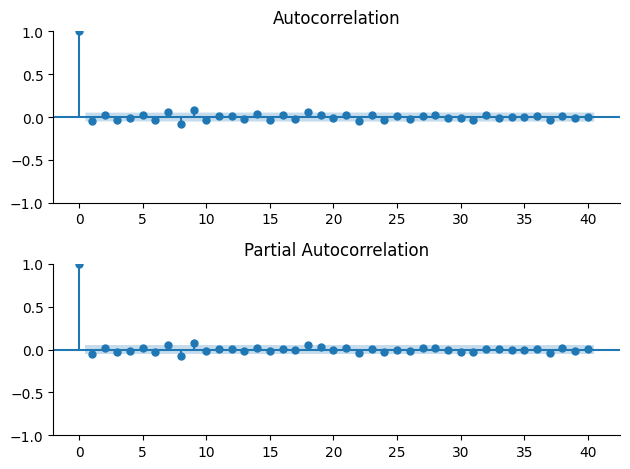

In [35]:
N_LAGS = 40
SIGNIFICANCE_LEVEL = 0.01

fig, ax = plt.subplots(2, 1)
plot_acf(return_data["log_return"], ax=ax[0], lags=N_LAGS, 
         alpha=SIGNIFICANCE_LEVEL)
plot_pacf(return_data["log_return"], ax=ax[1], lags=N_LAGS, 
          alpha=SIGNIFICANCE_LEVEL)

sns.despine()
plt.tight_layout()

In [26]:
#TODO Autocorrelation

In [ ]:
#TODO volatility clustering

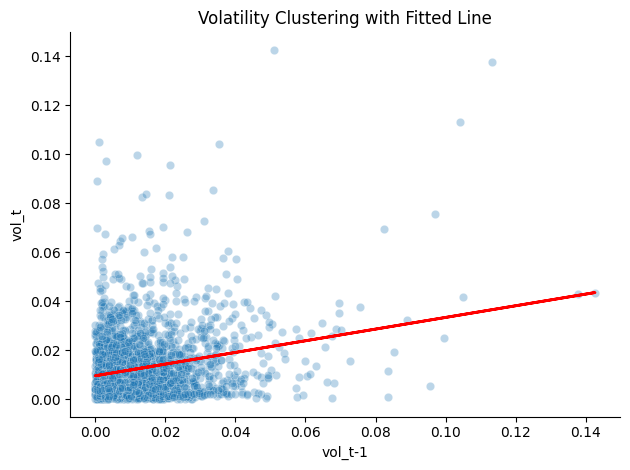

In [39]:
returns = return_data["log_return"]

sns.scatterplot(x="vol_t-1", y="vol_t", data=df_vol, alpha=0.3)

# Fit linear regression
x = df_vol["vol_t-1"]
y = df_vol["vol_t"]

m, b = np.polyfit(x, y, 1)

# Plot line
plt.plot(x, m*x + b, color="red", linewidth=2)

plt.title("Volatility Clustering with Fitted Line")
sns.despine()
plt.tight_layout()
plt.show()

##### Volatility Clustering – Scatterplot Interpretation

The fitted regression line exhibits a clear upward slope, indicating a positive relationship between lagged and current volatility.

This implies that periods of high volatility tend to be followed by further high volatility, while periods of low volatility are likely to be followed by continued calm conditions. In other words, volatility is persistent over time rather than randomly distributed.

Although the scatterplot is heavily concentrated near the origin—reflecting the fact that most daily returns are small—the upward trend in the fitted line reveals an underlying dependency structure. This pattern is consistent with the well-established phenomenon of volatility clustering in financial time series.

Overall, the result confirms that while returns themselves may appear random, their magnitude (volatility) exhibits temporal dependence, supporting the use of models that account for time-varying variance, such as GARCH.

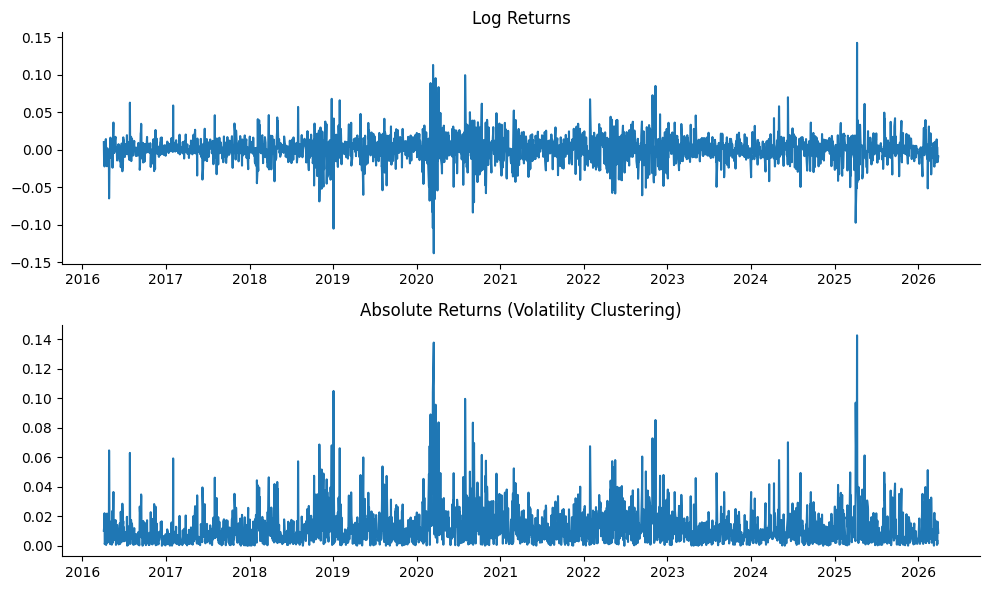

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot(returns)
ax[0].set_title("Log Returns")

ax[1].plot(returns.abs())
ax[1].set_title("Absolute Returns (Volatility Clustering)")

sns.despine()
plt.tight_layout()
plt.show()

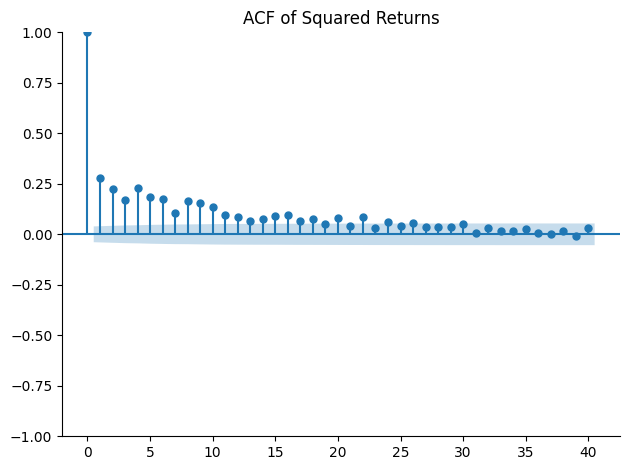

In [41]:
plot_acf(returns**2, lags=40)
plt.title("ACF of Squared Returns")
sns.despine()
plt.tight_layout()
plt.show()

##### Volatility Clustering: Concept and Importance

Volatility clustering is a fundamental property of financial time series, particularly evident in log returns. It refers to the empirical observation that large price movements tend to be followed by large movements (of either sign), and small movements tend to be followed by small ones. In other words, volatility is not constant over time but occurs in persistent “regimes” of high and low activity.

Importantly, this does **not** imply that returns themselves are predictable in direction. Instead, it indicates that the **magnitude** of returns exhibits temporal dependence.

##### Why Volatility Clustering Exists

Volatility clustering emerges due to underlying market dynamics such as:
- Information arrival (news shocks tend to have lasting effects)
- Behavioral responses (herding, panic, delayed reactions)
- Market microstructure effects (liquidity changes, order flow persistence)

These mechanisms create periods where uncertainty remains elevated or suppressed for extended intervals.


##### Why It Matters for Signal Extraction

At first glance, log return series appear close to random (white noise), making directional prediction difficult. However, volatility clustering introduces a key deviation from pure randomness:

> While returns are weakly predictable, **volatility is predictable**.

This has several important implications:

1. **Second-Order Signal (Variance Structure)**  
   Even if the mean of returns is unpredictable, the variance is not. This creates an opportunity to model and forecast risk.

2. **Regime Identification**  
   Clustering allows segmentation of the market into:
   - High-volatility regimes (risk-off, unstable)
   - Low-volatility regimes (risk-on, stable)

   These regimes can be used as filters for trading strategies.

3. **Improved Risk Management**  
   Time-varying volatility enables better position sizing and risk control. Ignoring clustering leads to underestimating risk during turbulent periods.

4. **Modeling Opportunities**  
   Volatility clustering justifies the use of models such as GARCH, which explicitly capture conditional heteroskedasticity (time-varying variance).

##### Why It Makes Sense in Practice

If markets were purely random:
- Volatility would be constant
- Large moves would be independent events

However, empirical data consistently shows:
- Persistence in volatility
- Serial correlation in squared/absolute returns

This means markets exhibit **structure in dispersion, not direction**.

From a trading perspective, this is critical:

> You may not predict *where* the market goes, but you can estimate *how violently* it will move.

This insight underpins:
- Volatility trading strategies
- Options pricing models
- Risk-adjusted portfolio allocation

##### Bottom Line

Volatility clustering transforms an apparently random log return series into a partially predictable system by introducing structure in variance. This makes it one of the most exploitable and practically relevant features in financial time series analysis.

**#TODO** Create raw returns dataset

In [ ]:
returns_df = data_pipe.build_returns_df(tickers, PROJECT_ROOT)
returns_df.to_csv(DATA_DIR / "stock_returns_static_dataset.csv")
returns_df

In [ ]:
close_price_df = data_pipe.build_close_price_df(tickers, PROJECT_ROOT)
close_price_df.to_csv(DATA_DIR / "stock_close_prices_static_dataset.csv")
close_price_df